In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
import random
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc
from tfrecordimagehandler import TFRecordImageHandler
from tfrecordhandler import TFRecordDataHandler
from src.datasplitting_for_images import DataSplittingForImages



In [2]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(image_batch, num_samples=5):
    plt.figure(figsize=(10, num_samples * 3))

    for i in range(num_samples):
        # Primer canal: la imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i, :, :, 0]), cmap='gray')  # Primer canal
        plt.title(f"Image")
        plt.axis('off')

        # Segundo canal: la máscara
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(image_batch[i, :, :, 1]), cmap='gray')  # Segundo canal
        plt.title(f"Mask ")
        plt.axis('off')

    plt.show()

In [3]:
# Definir hiperparámetros
INPUT_DIR = 'input/deep_learning'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

In [4]:
def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(image_path, mask_path):
    img = tf.io.decode_image(tf.io.read_file(image_path), channels=3)
    img_bytes = img.numpy().tobytes()

    mask = tf.io.decode_image(tf.io.read_file(mask_path), channels=1)
    mask_bytes = mask.numpy().tobytes()

    # Get Study, Mice group and Day of study from the path
    path = os.path.normpath(mask_path)
    
    # Divide el path en partes
    path_parts = path.split(os.sep)

    # Extraer las partes relevantes
    # 0 for Cured Mice, 1 for Relapsing Mice, 2 for Control Mice
    if path_parts[2] == 'Cured mice':
        group_name = 1
    elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
        group_name = 0
    elif path_parts[2] == 'Control':
        group_name = 0
    else:
        print(path_parts)
        raise ValueError('Invalid group')
    mouse_id = path_parts[3]       # 'C1281'
    day_of_study = path_parts[4]   # 'day10'

    # Get only the integers in ids
    mouse_id = mouse_id[1:]
    day_of_study = day_of_study[3:]

    feature = {
        'image': _bytes_feature(img_bytes),
        'mask': _bytes_feature(mask_bytes),
        'height': _int64_feature(img.shape[0]),
        'width': _int64_feature(img.shape[1]),
        'mask_height': _int64_feature(mask.shape[0]),
        'mask_width': _int64_feature(mask.shape[1]),
        'group_name': _int64_feature(int(group_name)),
        'mouse_id': _int64_feature(int(mouse_id)),
        'day_of_study': _int64_feature(int(day_of_study))
    }
    
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

def create_tfrecord(file_paths, output_file):
    with tf.io.TFRecordWriter(output_file) as writer:
        for img_path, mask_path in file_paths:
            if not os.path.exists(img_path) or not os.path.exists(mask_path):
                print(f'Image or mask not found: {img_path}, {mask_path}')
                continue
            writer.write(serialize_example(img_path, mask_path))

def split_dataset_by_m_id(root_dir, train_ratio=0.8):
    mouse_to_data = {}
    
    # Recorrer todas las imágenes y máscaras
    for data_group in os.listdir(root_dir):
        data_group_path = os.path.join(root_dir, data_group)
        if not os.path.isdir(data_group_path):
            continue
        for mice_group in os.listdir(data_group_path):
            mice_group_path = os.path.join(data_group_path, mice_group)
            if not os.path.isdir(mice_group_path):
                continue  # Saltar si no es un directorio
            for dayofstudy in os.listdir(mice_group_path):
                dayofstudy_path = os.path.join(mice_group_path, dayofstudy)
                if not os.path.isdir(dayofstudy_path):
                    continue  # Saltar si no es un directorio
                mri_imgs = os.path.join(dayofstudy_path, 'MRI images')
                if not os.path.exists(mri_imgs):
                    print(f"No se encontró la carpeta {mri_imgs}")
                    continue
                # Número de imágenes
                n_imgs = len(os.listdir(mri_imgs))
                for i in range(n_imgs):
                    img_path = os.path.join(mri_imgs, f'image_s{i + 1}.jpg')
                    mask_path = os.path.join(dayofstudy_path, f'Mask s{i + 1}.jpg')
                    
                    # Get Study, Mice group and Day of study from the path
                    path = os.path.normpath(mask_path)
                    
                    # Divide el path en partes
                    path_parts = path.split(os.sep)

                    # Extraer las partes relevantes
                    # 0 for Relapsing Mice, 1 for Cured Mice, 2 for Control Mice
                    if path_parts[2] == 'Cured mice':
                        group_name = 1
                    elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
                        group_name = 0
                    elif path_parts[2] == 'Control':
                        group_name = 0
                    else:
                        raise ValueError('Invalid group')
                    
                    mouse_id = path_parts[3]       # 'C1281'
                    day_of_study = path_parts[4]   # 'day10'

                    # Get only the integers in ids
                    mouse_id = mouse_id[1:]  # Remove 'C'
                    day_of_study = day_of_study[3:]  # Remove 'day'
                    
                    # Append data to mouse ID group
                    if mouse_id not in mouse_to_data:
                        mouse_to_data[mouse_id] = []
                    mouse_to_data[mouse_id].append((img_path, mask_path, group_name, mouse_id, day_of_study))

    # Split mouse IDs into train and test sets
    all_mice = list(mouse_to_data.keys())
    random.shuffle(all_mice)  # Shuffle IDs for randomness

    # Identify cured mice
    cured_mice = [mouse_id for mouse_id in all_mice if mouse_to_data[mouse_id][0][2] == 1]

    # Ensure at least one cured mouse in both train and test sets
    train_size = int(len(all_mice) * train_ratio)

    # Randomly shuffle cured mice to ensure diversity
    random.shuffle(cured_mice)

    # Ensure that at least one cured mouse is in the train and test sets
    train_mice = set(all_mice[:train_size])
    test_mice = set(all_mice[train_size:])

    # If the train set doesn't have a cured mouse, move one from test
    if not any(mouse_id in train_mice for mouse_id in cured_mice):
        train_mice.add(cured_mice[0])
        test_mice.remove(cured_mice[0])

    # If the test set doesn't have a cured mouse, move one from train
    if not any(mouse_id in test_mice for mouse_id in cured_mice):
        test_mice.add(cured_mice[0])
        train_mice.remove(cured_mice[0])

    # Check that both train and test sets have a cured mouse
    print(f'Train mice: {train_mice}')
    print(f'Test mice: {test_mice}')

    # Assign data to train and test sets
    train_data = [data for mouse_id in train_mice for data in mouse_to_data[mouse_id]]
    test_data = [data for mouse_id in test_mice for data in mouse_to_data[mouse_id]]

    train_paths = [(img, mask) for img, mask, *_ in train_data]
    test_paths = [(img, mask) for img, mask, *_ in test_data]

    print(f"Total data: {len(train_data) + len(test_data)}, Train: {len(train_data)}, Test: {len(test_data)}")
    
    return train_paths, test_paths

train_data, test_data = split_dataset_by_m_id(config.DATASET_DIR, train_ratio=0.7)
train_tfrefcord = os.path.join(INPUT_DIR, 'train.tfrecord')
test_tfrefcord = os.path.join(INPUT_DIR, 'test.tfrecord')

create_tfrecord(train_data, train_tfrefcord)
create_tfrecord(test_data, test_tfrefcord)

No se encontró la carpeta input\dataset\IMS-TMS-TREATED-RELAPSING\C1264\day41-No images\MRI images
Train mice: {'1360', '1383', '1380', '1270', '1361', '1261', '1264', '1258', '1359', '1299', '1260', '1285'}
Test mice: {'1382', '1263', '1276', '1297', '1284', '1281'}
Total data: 382, Train: 275, Test: 107


Number of train samples: 275
Number of test samples: 107
Number of batches: 8
Images min: 0.0, max: 1.0


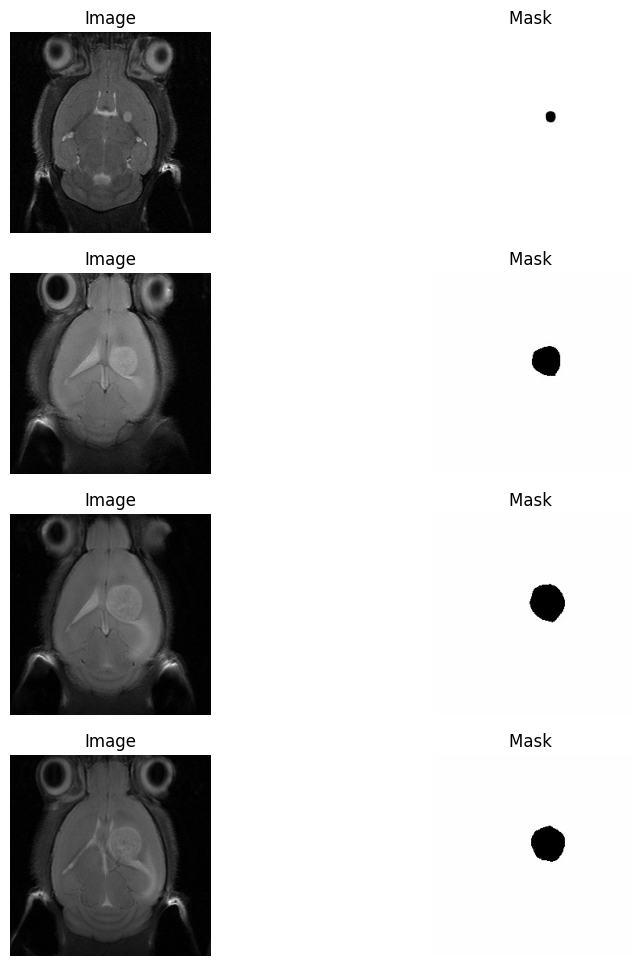

In [5]:
train_ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds = train_ds_handler.dataset
print(f"Number of train samples: {train_ds_handler.length}")

test_ds_handler = TFRecordImageHandler(test_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
test_ds = test_ds_handler.dataset
print(f"Number of test samples: {test_ds_handler.length}")

# Number of batches
n_batches = train_ds_handler.length // batch_size
print(f"Number of batches: {n_batches}")

images_tf, labels = next(iter(train_ds))

# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

visualize_data(images_tf, num_samples=4)
#visualize_data(images_tf, group_name_batches, num_samples=15)


In [6]:
# Print shape of images and masks
print(f"Images shape: {images_tf.shape}")

Images shape: (32, 256, 256, 3)


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import F1Score, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import cv2
import gc
import os
from datetime import datetime

# Define input_layer with the same shape that VGG16 expects
input_layer = tf.keras.layers.Input(shape=(256, 256, 3))

# Load the pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)

# Continue with custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Define the model
model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

model.summary()

# Oversampling with data augmentation
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, label

def count_instances(dataset):
    total_count = 0
    for images, labels in dataset:
        total_count += tf.size(labels)  # Count the number of labels (which equals the number of images in each batch)
    return total_count.numpy()  # Convert TensorFlow tensor to a regular integer

def oversample_minority_class(dataset, minority_class=1, factor=2):
    # Separate the minority and majority classes
    minority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl == minority_class))
    majority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl != minority_class))

    # Count instances before augmentation
    minority_count = count_instances(minority_ds)
    majority_count = count_instances(majority_ds)

    print(f"Before augmentation, Minority class size: {minority_count}, Majority class size: {majority_count}")
    
    # Augment the minority class data
    augmented_minority_ds = minority_ds.map(augment_data)
    for _ in range(factor - 1):
        augmented_minority_ds = augmented_minority_ds.concatenate(minority_ds.map(augment_data))

    # Recombine and shuffle
    balanced_ds = majority_ds.concatenate(augmented_minority_ds)
    
    # After oversampling, count again
    new_minority_count = count_instances(augmented_minority_ds)
    new_majority_count = count_instances(majority_ds)
    
    print(f"After augmentation, Minority class size: {new_minority_count}, Majority class size: {new_majority_count}")
    
    return balanced_ds.shuffle(buffer_size=1000)

# Apply oversampling to the dataset
train_ds = oversample_minority_class(train_ds, minority_class=1, factor=3)

from sklearn.metrics import f1_score

def f1_macro(y_true, y_pred):
    # Convert the predicted probabilities to class labels (argmax operation along axis=1)
    y_pred = tf.argmax(y_pred, axis=1)
    
    # If y_true is sparse (integer labels), no need to apply tf.argmax, just use y_true as is
    y_true = tf.cast(y_true, tf.int64)
    
    # Convert tensors to numpy arrays before passing to f1_score
    y_true = y_true.numpy()
    y_pred = y_pred.numpy()
    
    # Compute F1 score
    return f1_score(y_true, y_pred, average='macro')

# Define directory paths for saving the model and TensorBoard logs
log_dir = os.path.join("logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
model_save_path = "best_model.keras"

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath=model_save_path, monitor='val_loss', save_best_only=True, verbose=1)
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True, write_images=True)

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Change based on your label encoding
    metrics=['accuracy', AUC()]
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stopping, model_checkpoint, tensorboard_callback],
    verbose=1
)

# Print model save location and TensorBoard log directory
print(f"Best model saved to: {model_save_path}")
print(f"TensorBoard logs available at: {log_dir}")

# To visualize TensorBoard logs, use the following command in your terminal:
# tensorboard --logdir=logs

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,025 (58.14 MB)

 Trainable params: 15,241,025 (58.14 MB)

 Non-trainable params: 0 (0.00 B)

Before augmentation, Minority class size: 19, Majority class size: 275
After augmentation, Minority class size: 57, Majority class size: 275
Epoch 1/20


KeyboardInterrupt: 

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (1238082722.py, line 1)

In [ ]:
for layer in model.layers:
    print(layer.name)

input_layer_1
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
global_average_pooling2d_1
dense_2
dropout_1
dense_3


In [ ]:
# Función para obtener el heatmap de Grad-CAM
def get_gradcam_heatmap(model, img_array, class_index, layer_name="block5_conv3"):
    # Verificar que la capa existe en el modelo
    if layer_name not in [layer.name for layer in model.layers]:
        print(f"Error: La capa '{layer_name}' no se encuentra en el modelo.")
        return None
    
    # Crear un modelo que devuelva la salida de la capa de convolución y las predicciones
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    
    # Usar GradientTape para obtener los gradientes de la clase predicha respecto a la capa de convolución
    with tf.GradientTape() as tape:
        tape.watch(img_array)  # Asegurarnos de que el gradiente se calcula respecto a la imagen
        conv_output, predictions = grad_model(img_array)
    
    if predictions is None:
        print("Error: El modelo no está generando predicciones válidas.")
        return None

    # Convertir la clase de salida a un valor entero
    class_index = int(class_index)  # Asegurarse de que el índice de clase sea un valor entero
    class_output = predictions[:, class_index]
    
    # Calcular los gradientes de la clase con respecto a la salida de la capa convolucional
    grads = tape.gradient(class_output, conv_output)
    
    if grads is None:
        print("Error: No se pudieron calcular los gradientes.")
        return None
    
    # Promediar los gradientes sobre los ejes de alto y ancho (para obtener el gradiente global)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiplicar cada canal en el mapa de características por el gradiente medio
    conv_output = conv_output[0]
    for i in range(conv_output.shape[-1]):
        conv_output[:, :, i] *= pooled_grads[i]
    
    # Crear el heatmap promediando a través de los canales
    heatmap = tf.reduce_mean(conv_output, axis=-1)
    
    # Normalizar el heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap

# Función para generar Grad-CAM y mostrar las imágenes con su respectivo heatmap
def gradcam_visualization(model, test_ds, n_images=3, layer_name="block5_conv3"):
    # Obtener algunas imágenes y etiquetas del conjunto de prueba
    test_images, test_labels = next(iter(test_ds))
    
    # Plotear resultados para las primeras imágenes
    for i in range(n_images):
        img = test_images[i].numpy().astype("uint8")  # Convertir a numpy para visualización
        true_label = test_labels[i].numpy()  # Usar la etiqueta directamente
        
        # Obtener el heatmap de Grad-CAM
        heatmap = get_gradcam_heatmap(model, test_images[i:i+1], true_label, layer_name=layer_name)
        
        if heatmap is None:
            print(f"Error generando el heatmap para la imagen {i}.")
            continue
        
        # Superponer el heatmap en la imagen original
        superimposed_img = display_gradcam(img, heatmap)
        
        # Graficar la imagen original y la con el heatmap de Grad-CAM
        plt.figure(figsize=(12, 6))
        
        # Imagen original
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image (True: {true_label})")
        plt.axis('off')
        
        # Imagen con el heatmap de Grad-CAM
        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM Overlay (True: {true_label})")
        plt.axis('off')
        
        plt.show()

# Llamar a la función con el modelo y el conjunto de prueba
gradcam_visualization(model, test_ds, n_images=3, layer_name="block5_conv3")



Error: No se pudieron calcular los gradientes.
Error generando el heatmap para la imagen 0.
Error: No se pudieron calcular los gradientes.
Error generando el heatmap para la imagen 1.
Error: No se pudieron calcular los gradientes.
Error generando el heatmap para la imagen 2.
